# Tutorial for downloading HALO-TESS light curves
We first import the relevant Python modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import lightkurve as lk
import warnings

warnings.filterwarnings("ignore", category = RuntimeWarning)

We define the weightmap plotting function. Useful to check if the given TV minimisation has weighted the apropiate pixels

In [2]:
def plot_wmap(weightmap, name):
    norm = np.size(weightmap)
    cmap = mpl.cm.seismic
    cmap.set_bad('k',1.)

    im = np.log10(weightmap.T*norm)
    pic = plt.imshow(im, cmap = cmap, vmin = -2*np.nanmax(im),vmax =2*np.nanmax(im),
                    interpolation = None, origin = "lower")
    plt.title(f"TV-min Weightmap: {name}")

    plt.colorbar(pic,label = "log Weight")
    plt.show()

Now to download the light curve of a star. In this case we choose Polaris

In [3]:
lk.search_lightcurve("Polaris", author = "HALO-TESS")

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 19,2019,HALO-TESS,1798,303256075,0.0
1,TESS Sector 20,2019,HALO-TESS,1798,303256075,0.0
2,TESS Sector 25,2020,HALO-TESS,1798,303256075,0.0
3,TESS Sector 26,2020,HALO-TESS,1798,303256075,0.0
4,TESS Sector 40,2021,HALO-TESS,600,303256075,0.0
5,TESS Sector 47,2021,HALO-TESS,600,303256075,0.0
6,TESS Sector 59,2022,HALO-TESS,200,303256075,0.0
7,TESS Sector 60,2022,HALO-TESS,200,303256075,0.0
8,TESS Sector 52,2022,HALO-TESS,600,303256075,0.0


In [4]:
lightcurve = lk.search_lightcurve("Polaris", author = "HALO-TESS", sector = 73).download()

Note the downloaded file is TessTargetPixelFile object, not a light curve object.

Lets plot the timeseries of Polaris

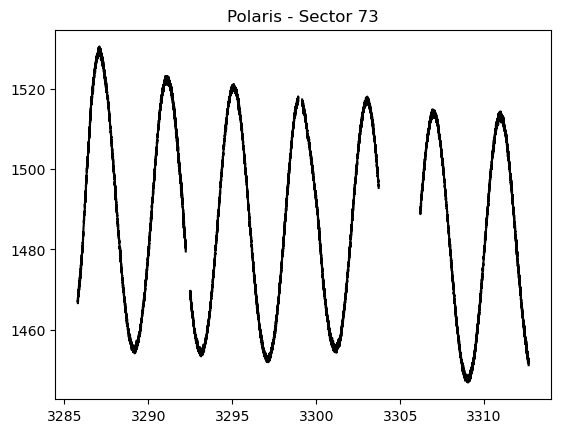

In [5]:
head_polaris = lightcurve.get_header() 

plt.plot(lightcurve.time.value, lightcurve.flux.value, color = "black")
plt.title(f"{head_polaris['NAME']} - Sector {head_polaris['Sector']}")
plt.show()

Let us visualise the weightmap of Polaris

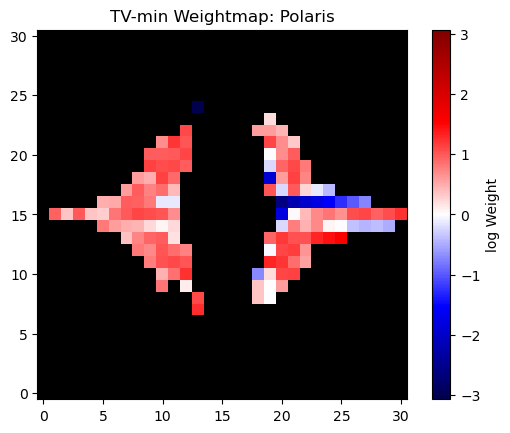

In [6]:
wm = lightcurve.hdu[2].data
plot_wmap(wm, head_polaris['NAME'])

Lets download another star. What about the newly discoveres $\delta$ Scuti-$\gamma$ Doradus variable $\alpha$ Cephei?

In [7]:
lk.search_lightcurve("alf Cep", author = "HALO-TESS")

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 16,2019,HALO-TESS,1798,417604820,0.0
1,TESS Sector 17,2019,HALO-TESS,1798,417604820,0.0
2,TESS Sector 24,2020,HALO-TESS,1798,417604820,0.0
3,TESS Sector 56,2022,HALO-TESS,200,417604820,0.0
4,TESS Sector 57,2022,HALO-TESS,200,417604820,0.0
5,TESS Sector 58,2022,HALO-TESS,200,417604820,0.0
6,TESS Sector 76,2024,HALO-TESS,200,417604820,0.0
7,TESS Sector 77,2024,HALO-TESS,200,417604820,0.0
8,TESS Sector 83,2024,HALO-TESS,200,417604820,0.0


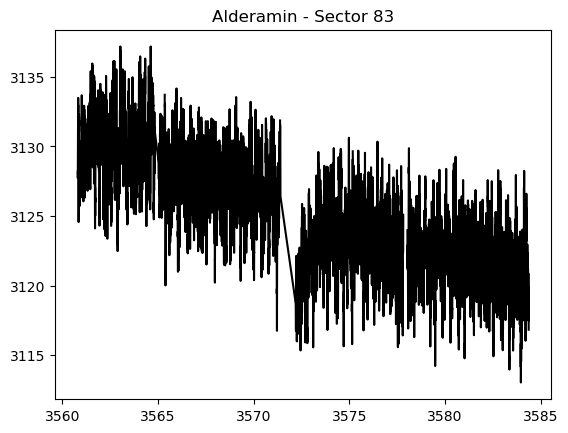

In [8]:
lc_alfcep = lk.search_lightcurve("alf Cep", author = "HALO-TESS", sector = 83).download()

head_alfcep = lc_alfcep.get_header() 

plt.plot(lc_alfcep.time.value, lc_alfcep.flux.value, color = "black")
plt.title(f"{head_alfcep['NAME']} - Sector {head_alfcep['Sector']}")
plt.show()

And visualize its weightmap

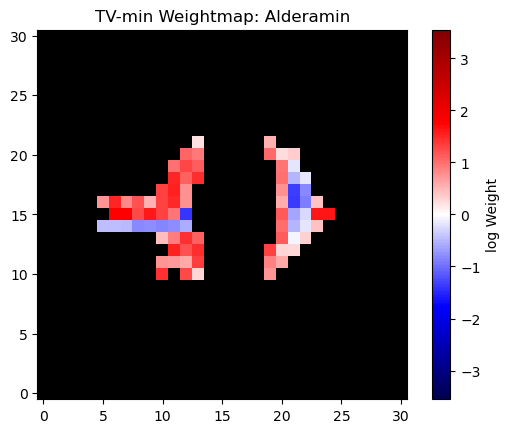

In [9]:
plot_wmap(lc_alfcep.hdu[2].data, head_alfcep['NAME'])